<a href="https://colab.research.google.com/github/Bennythomas333/final-year-project-/blob/main/notebooks/NIDS_Full_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NIDS Full Pipeline
Notebook was restored. Please re-run all cells.

In [1]:
!pip install -q lightgbm==4.3.0 imbalanced-learn shap --upgrade

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings, os, json
from pathlib import Path
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, roc_auc_score,
                              ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import shap

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
print("All libraries loaded")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 22.9 MB/s eta 0:00:00
All libraries loaded


In [3]:
USE_REAL_DATASET = False  # Set True if you have CICIDS-2017 CSVs in Drive

ATTACK_TYPES = [
    "BENIGN","DoS Hulk","PortScan","DDoS","DoS GoldenEye",
    "FTP-Patator","SSH-Patator","DoS Slowloris","DoS Slowhttptest",
    "Bot","Web Attack Brute Force","Web Attack XSS",
    "Web Attack Sql Injection","Infiltration","Heartbleed"
]
FEATURES = [
    "Flow Duration","Total Fwd Packets","Total Backward Packets",
    "Total Length of Fwd Packets","Total Length of Bwd Packets",
    "Fwd Packet Length Max","Fwd Packet Length Min",
    "Fwd Packet Length Mean","Fwd Packet Length Std",
    "Bwd Packet Length Max","Bwd Packet Length Min",
    "Bwd Packet Length Mean","Bwd Packet Length Std",
    "Flow Bytes/s","Flow Packets/s",
    "Flow IAT Mean","Flow IAT Std","Flow IAT Max","Flow IAT Min",
    "Fwd IAT Total","Fwd IAT Mean","Fwd IAT Std",
    "Bwd IAT Total","Bwd IAT Mean","Bwd IAT Std",
    "FIN Flag Count","SYN Flag Count","RST Flag Count",
    "PSH Flag Count","ACK Flag Count",
    "Packet Length Mean","Packet Length Std","Packet Length Variance",
    "Average Packet Size","Init_Win_bytes_forward","Init_Win_bytes_backward",
    "Fwd Packets/s","Bwd Packets/s",
    "Active Mean","Active Std","Idle Mean","Idle Std",
    "Subflow Fwd Packets","Subflow Bwd Packets",
    "Down/Up Ratio","Avg Fwd Segment Size","Avg Bwd Segment Size",
]

def generate_flow_block(n, label, intensity=1.0):
    rng = np.random.default_rng(abs(hash(label)) % (2**31))
    data = {f: np.abs(rng.exponential(1e4 * intensity, n)) for f in FEATURES}
    data["SYN Flag Count"] = rng.integers(0, max(1, int(5*intensity)+1), n)
    data["RST Flag Count"] = rng.integers(0, max(1, int(3*intensity)+1), n)
    data["FIN Flag Count"] = rng.integers(0, 3, n)
    data["ACK Flag Count"] = rng.integers(0, 10, n)
    data["Flow Bytes/s"]   = np.abs(rng.exponential(5e4 * intensity, n))
    data["Flow Packets/s"] = np.abs(rng.exponential(300 * intensity, n))
    data["Down/Up Ratio"]  = np.abs(rng.normal(1, 0.4, n))
    data["Label"] = [label] * n
    return pd.DataFrame(data)

def build_dataset(n_total=60_000):
    n_benign = int(n_total * 0.70)
    n_each   = (n_total - n_benign) // (len(ATTACK_TYPES) - 1)
    intensity_map = {
        "DoS Hulk":3.8,"DDoS":3.5,"PortScan":2.5,"DoS GoldenEye":3.0,
        "FTP-Patator":2.0,"SSH-Patator":2.0,"DoS Slowloris":2.5,
        "DoS Slowhttptest":2.5,"Bot":1.8,"Web Attack Brute Force":1.5,
        "Web Attack XSS":1.4,"Web Attack Sql Injection":1.4,
        "Infiltration":1.6,"Heartbleed":2.0
    }
    dfs = [generate_flow_block(n_benign, "BENIGN", 1.0)]
    for lbl in ATTACK_TYPES[1:]:
        dfs.append(generate_flow_block(n_each, lbl, intensity_map.get(lbl, 2.0)))
    return pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

if USE_REAL_DATASET:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = Path('/content/drive/MyDrive/CICIDS2017')
    dfs = [pd.read_csv(f, low_memory=False) for f in tqdm(list(DATA_DIR.glob('*.csv')))]
    df_raw = pd.concat(dfs, ignore_index=True)
    df_raw.columns = df_raw.columns.str.strip()
    df_raw.rename(columns={" Label":"Label"}, inplace=True)
else:
    print("Generating synthetic dataset (60,000 rows)...")
    df_raw = build_dataset(60_000)

print(f"Shape: {df_raw.shape}")
print(df_raw['Label'].value_counts())

Generating synthetic dataset (60,000 rows)...
Shape: (59990, 48)
Label
BENIGN                      42000
Bot                          1285
SSH-Patator                  1285
DoS GoldenEye                1285
Infiltration                 1285
Heartbleed                   1285
Web Attack Sql Injection     1285
DDoS                         1285
Web Attack Brute Force       1285
DoS Slowhttptest             1285
PortScan                     1285
FTP-Patator                  1285
Web Attack XSS               1285
DoS Slowloris                1285
DoS Hulk                     1285
Name: count, dtype: int64


In [4]:
df = df_raw.copy()
DROP = ["Flow ID","Source IP","Destination IP","Source Port","Destination Port","Timestamp"]
df.drop(columns=[c for c in DROP if c in df.columns], inplace=True)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.select_dtypes(include=np.number).median(), inplace=True)

le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["Label"])
df["is_attack"]  = (df["Label"] != "BENIGN").astype(int)

FEATURE_COLS = [c for c in df.columns if c not in ("Label","label_enc","is_attack")]
X = df[FEATURE_COLS].values
y = df["is_attack"].values

sel = VarianceThreshold(threshold=0.0)
X   = sel.fit_transform(X)
selected_features = [FEATURE_COLS[i] for i in range(len(FEATURE_COLS)) if sel.get_support()[i]]
print(f"Features: {X.shape[1]}")

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_tr   = scaler.fit_transform(X_tr)
X_te   = scaler.transform(X_te)

print(f"Before SMOTE — attack={y_tr.sum()} benign={(y_tr==0).sum()}")
sm = SMOTE(random_state=42)
X_tr, y_tr = sm.fit_resample(X_tr, y_tr)
print(f"After  SMOTE — attack={y_tr.sum()} benign={(y_tr==0).sum()}")
print(f"Train: {X_tr.shape}  Test: {X_te.shape}")

Features: 47
Before SMOTE — attack=14392 benign=33600
After  SMOTE — attack=33600 benign=33600
Train: (67200, 47)  Test: (11998, 47)


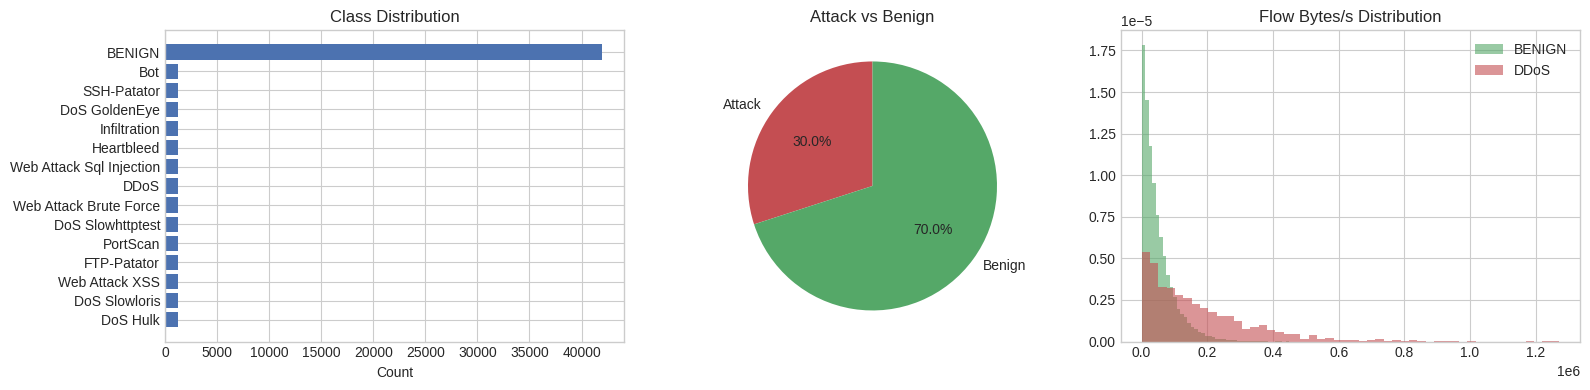

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

vc = df_raw['Label'].value_counts()
axes[0].barh(vc.index[::-1], vc.values[::-1], color=COLORS[0])
axes[0].set_title('Class Distribution'); axes[0].set_xlabel('Count')

axes[1].pie(
    [df['is_attack'].sum(), (df['is_attack']==0).sum()],
    labels=['Attack','Benign'], autopct='%1.1f%%',
    colors=[COLORS[3], COLORS[2]], startangle=90)
axes[1].set_title('Attack vs Benign')

for lbl, color in zip(['BENIGN','DDoS'], [COLORS[2], COLORS[3]]):
    sub = df_raw[df_raw['Label']==lbl]['Flow Bytes/s'].dropna().clip(0, 2e6)
    axes[2].hist(sub, bins=50, alpha=0.6, label=lbl, color=color, density=True)
axes[2].set_title('Flow Bytes/s Distribution'); axes[2].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_split=5,
    n_jobs=-1, random_state=42, class_weight='balanced')

xgb_clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0)

lgbm_clf = lgb.LGBMClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1)

ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb_clf), ('lgbm', lgbm_clf)],
    voting='soft', n_jobs=-1)

models = {
    'Random Forest': rf,
    'XGBoost':       xgb_clf,
    'LightGBM':      lgbm_clf,
    'Ensemble':      ensemble,
}

results = {}
for name, model in models.items():
    print(f"Training {name}...", end=' ', flush=True)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    results[name] = dict(
        accuracy=accuracy_score(y_te, y_pred),
        f1=f1_score(y_te, y_pred, average='macro'),
        auc=roc_auc_score(y_te, y_prob),
        model=model, y_pred=y_pred)
    print(f"Acc={results[name]['accuracy']:.4f}  F1={results[name]['f1']:.4f}")
print("All models trained!")

Training Random Forest... Acc=0.9574  F1=0.9472
Training XGBoost... Acc=0.9648  F1=0.9571
Training LightGBM... Acc=0.9657  F1=0.9583
Training Ensemble... Acc=0.9650  F1=0.9572
All models trained!


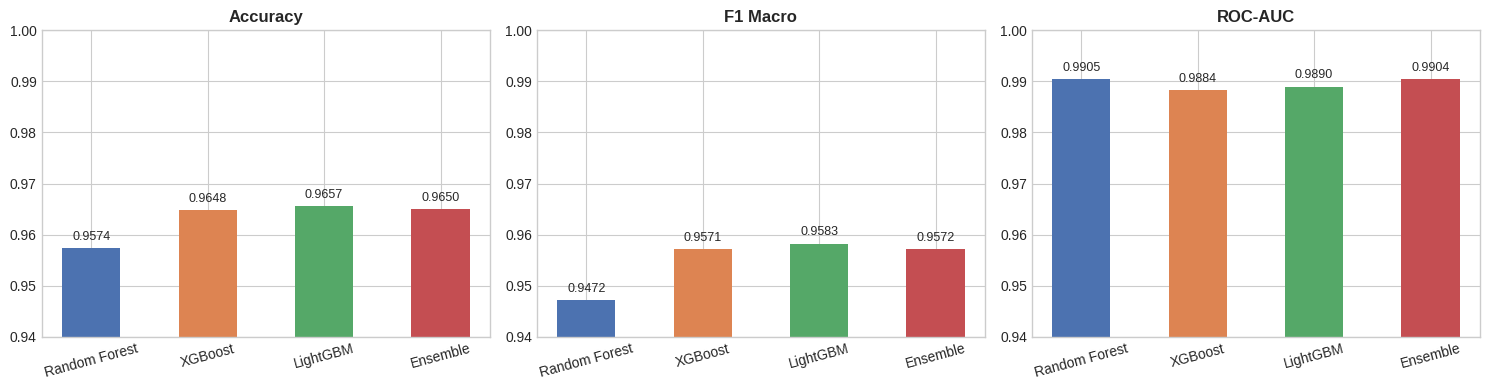

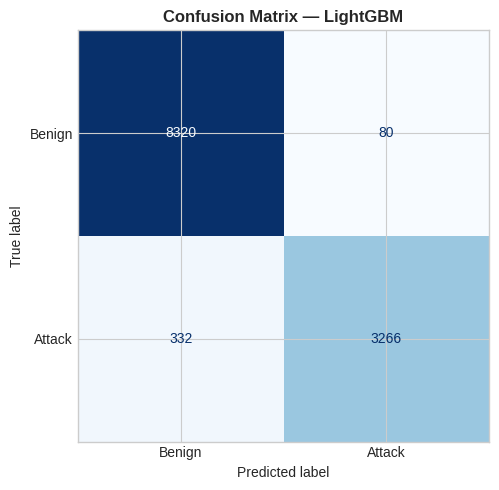

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.98      8400
      Attack       0.98      0.91      0.94      3598

    accuracy                           0.97     11998
   macro avg       0.97      0.95      0.96     11998
weighted avg       0.97      0.97      0.97     11998



In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
names   = list(results.keys())
metrics = ['accuracy', 'f1', 'auc']
titles  = ['Accuracy', 'F1 Macro', 'ROC-AUC']
for ax, metric, title in zip(axes, metrics, titles):
    vals = [results[n][metric] for n in names]
    bars = ax.bar(names, vals, color=COLORS[:len(names)], width=0.5)
    ax.set_ylim(0.94, 1.0); ax.set_title(title, fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_name = max(results, key=lambda k: results[k]['f1'])
cm = confusion_matrix(y_te, results[best_name]['y_pred'])
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=['Benign','Attack']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_te, results[best_name]['y_pred'],
                             target_names=['Benign','Attack']))

Computing SHAP values on 500 test samples...


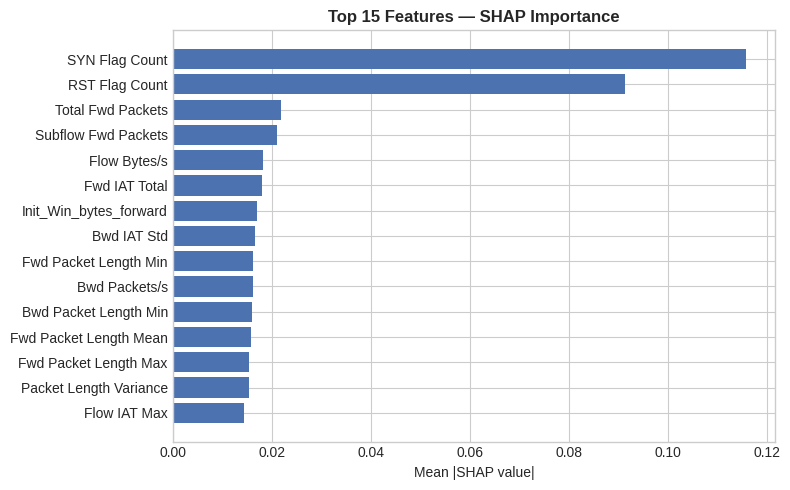

In [8]:
print("Computing SHAP values on 500 test samples...")
explainer  = shap.TreeExplainer(rf)
shap_vals  = explainer.shap_values(X_te[:500])

# Fix: handle all SHAP output formats
if isinstance(shap_vals, list):
    sv = np.array(shap_vals[1])
else:
    sv = np.array(shap_vals)

# Fix: handle 3D array from newer SHAP versions
if sv.ndim == 3:
    sv = sv[:, :, 1]

mean_abs  = np.abs(sv).mean(axis=0)
top_idx   = np.argsort(mean_abs)[-15:][::-1]
# Fix: convert numpy index to Python int before indexing list
top_feats = [selected_features[int(i)] for i in top_idx]
top_vals  = mean_abs[top_idx]

fig, ax = plt.subplots(figsize=(8,5))
ax.barh(top_feats[::-1], top_vals[::-1], color=COLORS[0])
ax.set_title('Top 15 Features — SHAP Importance', fontweight='bold')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
os.makedirs('models', exist_ok=True)
for name, res in results.items():
    fname = 'models/' + name.lower().replace(' ','_') + '.pkl'
    joblib.dump(res['model'], fname)
    print(f"Saved {fname}")

joblib.dump(scaler,            'models/scaler.pkl')
joblib.dump(le,                'models/label_encoder.pkl')
joblib.dump(selected_features, 'models/feature_names.pkl')

summary = {k: {'accuracy': v['accuracy'], 'f1': v['f1'], 'auc': v['auc']}
           for k,v in results.items()}
with open('models/evaluation.json','w') as f:
    json.dump(summary, f, indent=2)

print("\nAll artifacts saved to models/")
for f in sorted(Path('models').glob('*')): print(' ', f)

# Uncomment to save to Google Drive:
# from google.colab import drive; drive.mount('/content/drive')
# !cp -r models/ /content/drive/MyDrive/NIDS_models/

Saved models/random_forest.pkl
Saved models/xgboost.pkl
Saved models/lightgbm.pkl
Saved models/ensemble.pkl

All artifacts saved to models/
  models/ensemble.pkl
  models/evaluation.json
  models/feature_names.pkl
  models/label_encoder.pkl
  models/lightgbm.pkl
  models/random_forest.pkl
  models/scaler.pkl
  models/xgboost.pkl


In [10]:
import ipywidgets as widgets
from IPython.display import display, HTML
best_name = max(results, key=lambda k: results[k]['f1'])
best_model = results[best_name]['model']

style  = {'description_width': '220px'}
layout = widgets.Layout(width='440px')

w_bytes   = widgets.FloatSlider(value=5e5, min=0, max=1e7, step=1e4,
                                description='Flow Bytes/s:',        style=style, layout=layout)
w_pkts    = widgets.FloatSlider(value=500, min=0, max=20000, step=10,
                                description='Flow Packets/s:',      style=style, layout=layout)
w_syn     = widgets.IntSlider(value=1, min=0, max=50,
                              description='SYN Flag Count:',        style=style, layout=layout)
w_dur     = widgets.FloatSlider(value=5e5, min=0, max=1e8, step=1e4,
                                description='Flow Duration (us):',  style=style, layout=layout)
w_fwd_len = widgets.FloatSlider(value=500, min=0, max=5000, step=10,
                                description='Fwd Pkt Length Mean:', style=style, layout=layout)
w_iat     = widgets.FloatSlider(value=1e5, min=0, max=1e7, step=1000,
                                description='Flow IAT Mean:',       style=style, layout=layout)

btn = widgets.Button(description='Predict', button_style='primary',
                     layout=widgets.Layout(width='120px'))
out = widgets.Output()

def predict_flow(_):
    out.clear_output()
    flow_vals = {
        'Flow Bytes/s':           w_bytes.value,
        'Flow Packets/s':         w_pkts.value,
        'SYN Flag Count':         float(w_syn.value),
        'Flow Duration':          w_dur.value,
        'Fwd Packet Length Mean': w_fwd_len.value,
        'Flow IAT Mean':          w_iat.value,
    }
    x     = np.array([[flow_vals.get(f, 0.0) for f in selected_features]])
    x_sc  = scaler.transform(x)
    pred  = best_model.predict(x_sc)[0]
    proba = best_model.predict_proba(x_sc)[0]
    conf  = proba[pred] * 100
    label = 'ATTACK' if pred == 1 else 'BENIGN'
    color = '#dc3545' if pred == 1 else '#198754'
    icon  = 'WARNING' if pred == 1 else 'SAFE'
    with out:
        display(HTML(
            "<div style='padding:14px;border-radius:8px;border:2px solid " + color +
            ";background:" + color + "18;font-family:monospace;margin-top:10px'>"
            "<h3 style='color:" + color + ";margin:0'>[" + icon + "] Prediction: " + label + "</h3>"
            "<p style='margin:6px 0'>Confidence: <strong>" + f"{conf:.1f}%" + "</strong></p>"
            "<p style='margin:6px 0'>Benign: " + f"{proba[0]*100:.1f}% | Attack: {proba[1]*100:.1f}%" + "</p>"
            "<p style='margin:6px 0'>Model: " + best_name + "</p>"
            "</div>"
        ))

btn.on_click(predict_flow)
display(widgets.VBox([
    widgets.HTML("<h3>NIDS Live Prediction Demo</h3>"),
    w_bytes, w_pkts, w_syn, w_dur, w_fwd_len, w_iat,
    btn, out
]))

In [11]:
sample = pd.DataFrame({
    'Flow Bytes/s':           [100,   5e6,   1e7,  50,   2e5],
    'Flow Packets/s':         [20,    8000,  15000, 5,   300],
    'SYN Flag Count':         [1,     20,    30,    0,   2],
    'Flow Duration':          [1e6,   5e4,   2e4,   2e6, 5e5],
    'Fwd Packet Length Mean': [800,   100,   60,    1200,500],
    'Flow IAT Mean':          [5e4,   5e3,   2e3,   1e5, 2e4],
})

X_b    = np.array([[sample[f].values[i] if f in sample.columns else 0.0
                    for f in selected_features] for i in range(len(sample))])
X_b_sc = scaler.transform(X_b)
preds  = best_model.predict(X_b_sc)
probas = best_model.predict_proba(X_b_sc)

sample['Prediction'] = ['ATTACK' if p else 'BENIGN' for p in preds]
sample['Confidence'] = [f"{probas[i][p]*100:.1f}%" for i,p in enumerate(preds)]
print(sample[['Prediction','Confidence','Flow Bytes/s','SYN Flag Count']].to_string())

  Prediction Confidence  Flow Bytes/s  SYN Flag Count
0     BENIGN     100.0%         100.0               1
1     ATTACK      82.1%     5000000.0              20
2     ATTACK      81.2%    10000000.0              30
3     BENIGN     100.0%          50.0               0
4     BENIGN     100.0%      200000.0               2


In [12]:
print("=" * 55)
print("  NIDS ML PROJECT - FINAL RESULTS")
print("=" * 55)
for name, res in results.items():
    star = " * BEST" if name == best_name else ""
    print(f"{name:<18} Acc={res['accuracy']:.4f}  F1={res['f1']:.4f}  AUC={res['auc']:.4f}{star}")
print("=" * 55)



  NIDS ML PROJECT - FINAL RESULTS
Random Forest      Acc=0.9574  F1=0.9472  AUC=0.9905
XGBoost            Acc=0.9648  F1=0.9571  AUC=0.9884
LightGBM           Acc=0.9657  F1=0.9583  AUC=0.9890 * BEST
Ensemble           Acc=0.9650  F1=0.9572  AUC=0.9904
